### **Lab 4: การพัฒนาแบบจำลอง Machine Learning สำหรับการจำแนกพื้นที่ป่าด้วยข้อมูลภาพถ่ายดาวเทียม**

พื้นที่ศึกษา: จังหวัดเลย

ข้อมูลที่ใช้: 1. ขอบเขตจังหวัดเลย 2. ข้อมูลจุดประเภทการใช้ที่ดิน ปี 2562 โดยแบ่งเป็น พื้นที่ป่าไม้ 500 จุดและพื้นที่ที่ไม่ใช่ป่าไม้ 500 จุด รวมทั้งหมด 1000จุด สร้างจาก เปลี่ยนแปลง polygon เป็น point โดยโปรแกรม ArcGIS Pro และ 3. sentinel 2 จาก GEE

การแบ่งฝึกสอนและทดสอบ : 70:30 สำหรับสร้างแบบจำลอง ML โดยแบบจำลองที่ใช้ คือ แบบจำลอง random forest เป็น การเรียนรู้แบบรวมกลุ่ม โดยใช้ decision trees ในการฝึกสอน และโหวตค่าหรือผลลัพธ์ที่ดีที่สุด ที่ได้จาก decision trees ในการจำแนกพื้นที่ป่าไม้ และแบบจำลอง Support Vector Machines (SVM)  เป็น อัลกอริธึม การเรียนรู้ของเครื่องแบบมีผู้กำกับดูแลซึ่งจำแนกข้อมูลโดยการค้นหาเส้นหรือระนาบไฮเปอร์ที่เหมาะสมที่สุด

ตัวแปรตาม คือ จุดพื้นที่ป่าไม้และจุดไม่ใช่พื้นที่ป่าไม้

ตัวแปรอิสระ 9 ตัว ได้แก่ B2, B3, B4, B8, B11, EVI, NBR, NDVI, NDWIและปัจจัยเหล่านี้จะต้องผ่านการคัดเลือก จาก การทดสอบ Exploratory Data Analysis (EDA)คือ กระบวนการตรวจสอบและสำรวจข้อมูลเบื้องต้น เป็นการวิเคราะห์ข้อมูลที่จำเป็นก่อนการนำข้อมูลเข้าไปฝึกสอนในโมเดล


### 1. การเตรียมข้อมูล




In [1]:
!pip install pycrs

  Preparing metadata (setup.py) ... done
  Created wheel for pycrs: filename=PyCRS-1.0.2-py3-none-any.whl size=32686 sha256=01a1651edc9f0759cd8134b885906da124ca523a75c447ea890040204f9b74d2
  Stored in directory: /root/.cache/pip/wheels/b5/4a/72/1ba05f57ddf2cc80ad21a26512097762561d646ff3ff85f729
Successfully built pycrs


In [2]:
!pip install rasterio geopandas scikit-learn folium -q

In [3]:
import ee
import geemap
import pandas as pd
import geopandas as gpd
import rasterio
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt


In [6]:
ee.Authenticate()
ee.Initialize(project='ee-khehathancencira')

In [73]:
Map = geemap.Map()
roi = geemap.shp_to_ee('/content/loei.shp')

Map.centerObject(roi, 8)
Map.addLayer(roi, {}, "ROI")

### **การเตรียมข้อมูล**
•	โหลดข้อมูลภาพถ่ายดาวเทียม และแสดง Metadata

•	โหลดข้อมูลจุดตัวอย่างของพื้นที่ประเภทต่างๆ

•	คำนวณ NDVI และดึงค่าของ Band ต่างๆ มาใช้เป็น Features


In [9]:
sentinel = (
    ee.ImageCollection("COPERNICUS/S2_SR")
    .filterBounds(roi)
    .filterDate("2023-01-01","2023-12-31")
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE",20))
    .select(['B2','B3','B4','B8','B11'])
    .median()
    .clip(roi)
)

In [10]:
ndvi = sentinel.normalizedDifference(['B8','B4']).rename("NDVI")
ndwi = sentinel.normalizedDifference(['B3','B8']).rename("NDWI")
nbr  = sentinel.normalizedDifference(['B8','B11']).rename("NBR")

# EVI
evi = sentinel.expression(
    '2.5 * ((NIR - RED) / (NIR + 6*RED - 7.5*BLUE + 1))',
    {
        'NIR': sentinel.select('B8'),
        'RED': sentinel.select('B4'),
        'BLUE': sentinel.select('B2')
    }
).rename('EVI')

# รวม band
#image = sentinel.addBands([ndvi, ndwi, nbr, evi])

In [11]:
image = sentinel.select(['B2','B3','B4','B8','B11']).addBands([ndvi, ndwi, nbr, evi])

In [12]:
Map.addLayer(
    sentinel,
    {"bands":["B4","B3","B2"],"min":0,"max":3000},
    "RGB"
)
Map.addLayer(
    ndvi,
    {"min":-1, "max":1, "palette":["blue","white","green"]},
    "NDVI"
)

Map.addLayer(
    ndwi,
    {"min":-1, "max":1, "palette":["brown","white","blue"]},
    "NDWI"
)

Map.addLayer(
    nbr,
    {"min":-1, "max":1, "palette":["white","yellow","red","green"]},
    "NBR"
)

Map.addLayer(
    evi,
    {"min":-1, "max":1, "palette":["white","lightgreen","darkgreen"]},
    "EVI"
)

In [13]:
samples = pd.read_csv('/content/point_f.csv')

# Use pyproj to transform POINT_X and POINT_Y to longitude and latitude
from pyproj import Transformer

# Assume original coordinates are in UTM Zone 47N (EPSG:32647)
transformer = Transformer.from_crs("EPSG:32647", "EPSG:4326", always_xy=True)

lon_coords, lat_coords = transformer.transform(samples['POINT_X'].values, samples['POINT_Y'].values)

samples['lon'] = lon_coords
samples['lat'] = lat_coords

gdf = gpd.GeoDataFrame(
    samples,
    geometry=gpd.points_from_xy(samples.lon, samples.lat),
    crs="EPSG:4326"
)

In [14]:
points = geemap.geopandas_to_ee(gdf)

training = image.sampleRegions(
    collection = points,
    properties=['class'],
    scale=10
)

data = geemap.ee_to_df(training)

print(data.head())

      B11      B2      B3      B4      B8       EVI       NBR      NDVI  \
0  3561.5  1482.0  1686.5  1687.5  3320.0  1.750858 -0.035094  0.326011   
1  2819.0  1404.0  1511.0  1394.0  3407.0  4.051932  0.094443  0.419288   
2  3335.0  1435.0  1657.0  1543.0  3674.0  2.454504  0.048366  0.408472   
3  3385.0  1422.0  1621.0  1610.0  3108.0  1.779943 -0.042661  0.317507   
4  2686.0  1378.0  1494.0  1432.0  3270.0  3.007199  0.098052  0.390897   

       NDWI  class  
0 -0.326276      1  
1 -0.385523      1  
2 -0.378353      1  
3 -0.314443      1  
4 -0.372796      1  


In [17]:
# แปลงกลับเป็น DataFrame
sample_list = training.getInfo()['features']
rows = []
for f in sample_list:
    prop = f['properties']
    rows.append(prop)

df_ml = pd.DataFrame(rows)
df_ml = df_ml.dropna()  # ลบแถวที่ไม่มีค่า (no-data pixel)

print(f'✅ ดึงค่า Features สำเร็จ: {df_ml.shape}')
print(f'\nClass distribution:')
print(df_ml['class'].value_counts())
df_ml.head()

✅ ดึงค่า Features สำเร็จ: (1000, 10)

Class distribution:
class
1    500
0    500
Name: count, dtype: int64


,B11,B2,B3,B4,B8,EVI,NBR,NDVI,NDWI,class
0,3561.5,1482.0,1686.5,1687.5,3320.0,1.750858,-0.035094,0.326011,-0.326276,1
1,2819.0,1404.0,1511.0,1394.0,3407.0,4.051932,0.094443,0.419288,-0.385523,1
2,3335.0,1435.0,1657.0,1543.0,3674.0,2.454504,0.048366,0.408472,-0.378353,1
3,3385.0,1422.0,1621.0,1610.0,3108.0,1.779943,-0.042661,0.317507,-0.314443,1
4,2686.0,1378.0,1494.0,1432.0,3270.0,3.007199,0.098052,0.390897,-0.372796,1


### **การเตรียมข้อมูลสำหรับ Machine Learning**

•	รวมข้อมูลจาก Raster และเวกเตอร์เป็น DataFrame

•	แบ่งชุดข้อมูลเป็น Training และ Testing Set

•	ปรับขนาดข้อมูลและเลือก Features ที่สำคัญ


**คำนวณ Exploratory Data Analysis (EDA)**

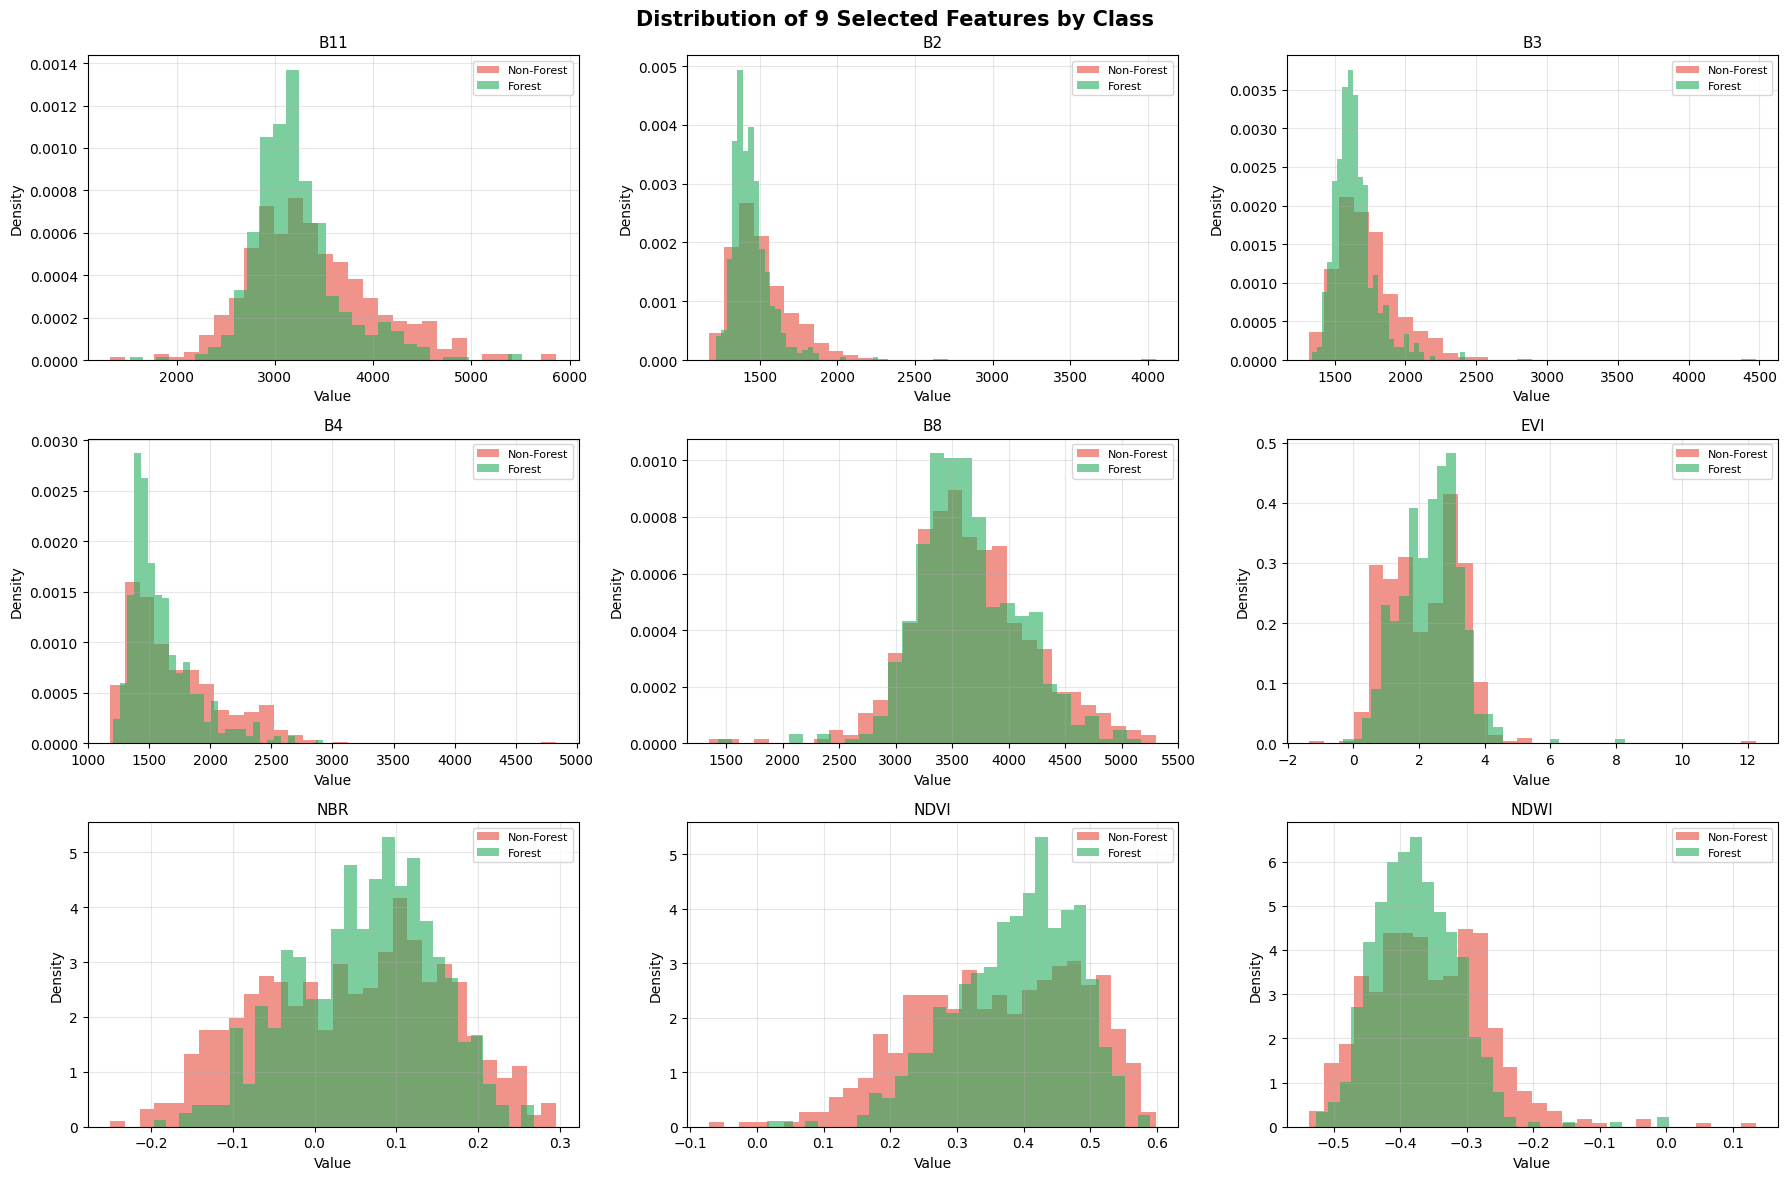

✅ แสดงการกระจายของ features สำเร็จ


In [19]:
import matplotlib.pyplot as plt
import numpy as np

# Get the number of features
feature_cols = [c for c in df_ml.columns if c not in ['class', 'CID']]
num_features = len(feature_cols)

# Determine the grid size for subplots
# A 3x3 grid will perfectly fit 9 features.
n_rows = 3
n_cols = 3
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12)) # Adjusted from (2, 4) to (3, 3) and adjusted figsize
fig.suptitle(f'Distribution of {num_features} Selected Features by Class', fontsize=15, fontweight='bold') # Dynamic title

colors_cls = {0: '#E74C3C', 1: '#27AE60'}
labels_cls = {0: 'Non-Forest', 1: 'Forest'}

# Flatten the axes array for easier iteration regardless of grid dimensions
axes_flat = axes.flatten()

for i, feat in enumerate(feature_cols):
    ax = axes_flat[i] # Use flattened array for direct indexing
    for cls in [0, 1]:
        vals = df_ml[df_ml['class'] == cls][feat]
        ax.hist(vals, bins=30, alpha=0.6, color=colors_cls[cls],
                label=labels_cls[cls], density=True)
    ax.set_title(feat, fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

# Hide any unused subplots if the number of features is less than n_rows * n_cols
for j in range(num_features, n_rows * n_cols):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig('feature_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

จาก Distribution Analysis

Feature แยก class ได้NDVI, B8 ดีที่สุด
 EVI, B4 พอประมาณ
 B2, B3, B11, NBR, NDWI  และน้อยและคัดออกไม่นำเข้าสู่โมเดล

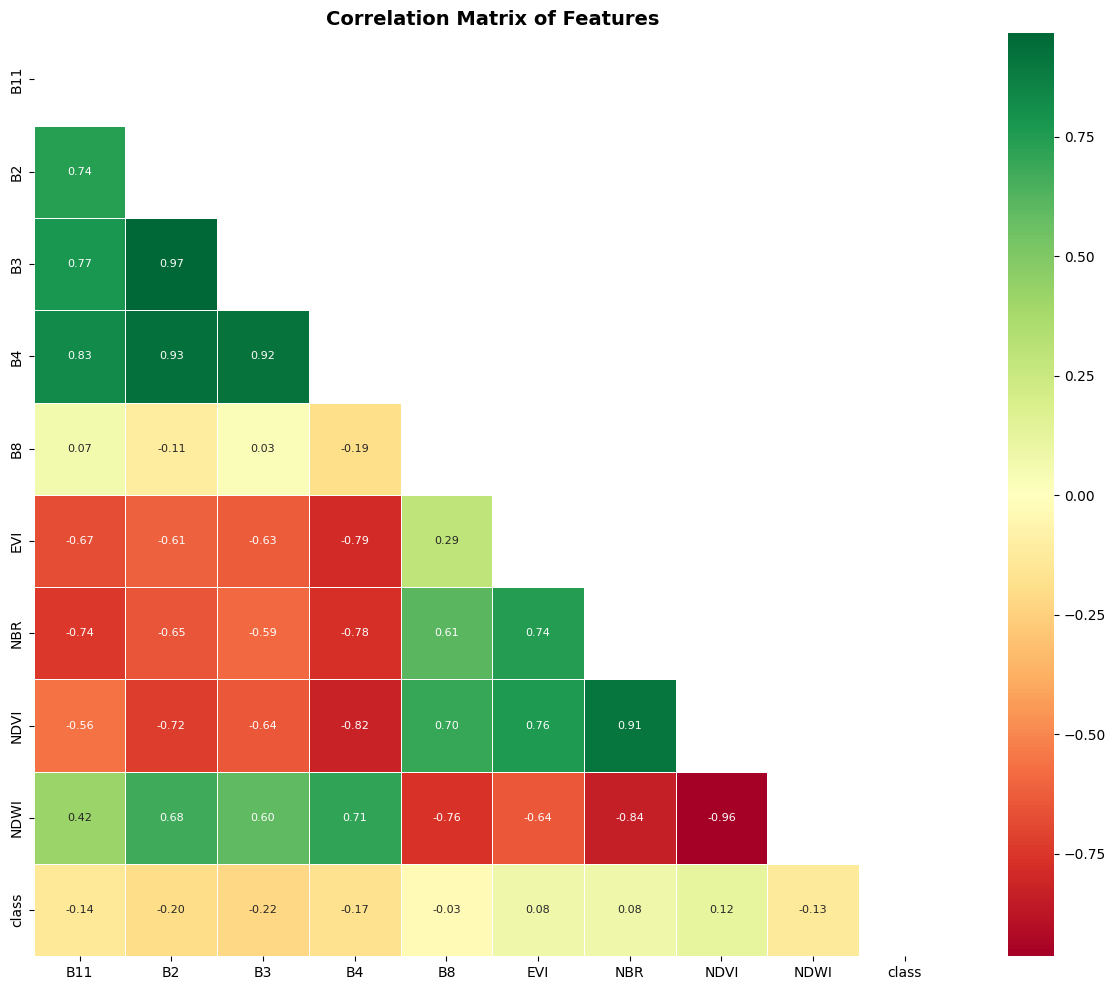

In [21]:
import seaborn as sns
# Correlation Matrix
plt.figure(figsize=(12, 10))
corr = df_ml[feature_cols + ['class']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Correlation Matrix of Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

ผลทดสอบ Multicollinearity

B2, B3, และ B4 = 0.92–0.97 (ซ้ำซ้อนมาก)
NDVI และ  NDWI = −0.96, NDVI และ NBR = 0.91 (ซ้ำซ้อนมาก)  ดังนั้นปัจจัยที่ซ้ำว้อนกันมากจะไม่นำเข้าสู่โมเดล

**ดังนั้น ปัจจัยที่จะนำเข้าสู่โมเดล มีทั้งหมด 4 โมเดล**

In [54]:
X = data[['NDVI', 'B8', 'EVI', 'B4']]
y = data['class']

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    stratify=y,
    random_state=42
)

### **การฝึกและทดสอบแบบจำลอง**
•	ใช้ Random Forest หรือ SVM สำหรับจำแนกประเภทของพื้นที่

•	ใช้ Grid Search เพื่อปรับพารามิเตอร์ของแบบจำลอง

•	ประเมินผลแบบจำลองด้วยค่า Accuracy, Confusion Matrix และ Classification Report


**RF**

In [57]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [5, 10, 20]
}

grid = GridSearchCV(
    rf, param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)
model = grid.best_estimator_

print("params :", grid.best_params_)
print("f1  :", grid.best_score_.round(4))

params : {'max_depth': 5, 'n_estimators': 200}
f1  : 0.6361


In [58]:
rf = RandomForestClassifier()

param_grid = {
    'n_estimators':[50,100,200],
    'max_depth':[5,10,20]
}

grid = GridSearchCV(rf, param_grid, cv=3)

grid.fit(X_train,y_train)

model = grid.best_estimator_

print(model)

RandomForestClassifier(max_depth=5, n_estimators=200)


**SVM**

In [59]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [68]:
#  SVM
svm = SVC(kernel='rbf', C=10, gamma='scale')
svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

### **การแสดงผลข้อมูล**
•	สร้างแผนที่แสดงผลการจำแนกพื้นที่

•	วิเคราะห์ความแม่นยำของแบบจำลอง


**RF**

In [72]:
print("=== RF ===")
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test,y_pred)
print("Accuracy:", accuracy_score(y_test,y_pred))
print(cm)
print(classification_report(y_test,y_pred))

=== RF ===
Accuracy: 0.6133333333333333
[[ 73  77]
 [ 39 111]]
              precision    recall  f1-score   support

           0       0.65      0.49      0.56       150
           1       0.59      0.74      0.66       150

    accuracy                           0.61       300
   macro avg       0.62      0.61      0.61       300
weighted avg       0.62      0.61      0.61       300



SVM

In [71]:
print("=== SVM ===")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

=== SVM ===
Accuracy: 0.5733333333333334
              precision    recall  f1-score   support

           0       0.71      0.25      0.37       150
           1       0.54      0.90      0.68       150

    accuracy                           0.57       300
   macro avg       0.63      0.57      0.52       300
weighted avg       0.63      0.57      0.52       300



In [63]:
classifier = ee.Classifier.smileRandomForest(100).train(
    features = training,
    classProperty='class',
    inputProperties=['NDVI', 'B8', 'EVI', 'B4']
)

# Explicitly cast the classified image to Uint8 to ensure numeric pixel values
classified = image.classify(classifier).toUint8()

In [64]:


importance = model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

  Feature  Importance
3      B4    0.322064
0    NDVI    0.277858
2     EVI    0.238678
1      B8    0.161400


In [65]:

from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selector.fit(X_train, y_train)


importance = pd.Series(
    rf_selector.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("=== Feature Importance ===")
print(importance)

=== Feature Importance ===
B4      0.263616
EVI     0.260146
NDVI    0.251799
B8      0.224439
dtype: float64


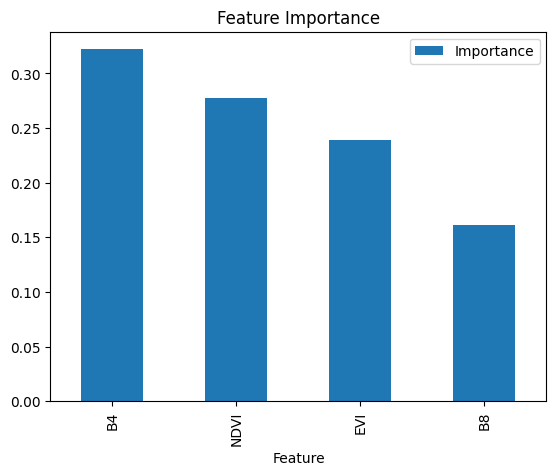

In [66]:
feature_importance.plot(
    x='Feature',
    y='Importance',
    kind='bar'
)

plt.title("Feature Importance")
plt.show()

**กำหนดให้ พื้นที่ป่าไม้ แสดงโดย สีเขียว และพื้นที่ไม่ใช่ป่าไม้ แสดงโดย สีเทา**

In [67]:

forest_map = classified.eq(1)

Map.addLayer(
    forest_map,
    {"min":0,"max":1,"palette":["gray","green"]},
    "Forest / Non-Forest"
)

Map

Map(bottom=118647.0, center=[17.210328948005895, 101.64894104003908], controls=(WidgetControl(options=['positi…

**Calculate Spectral Indices**

คำถามท้าย Lab

---


1.	ทำไมการเลือก Features ที่เหมาะสมจึงสำคัญใน Machine Learning?
คำตอบ: เพื่อเลือก ฟีเจอร์มีผลต่อประสิทธิภาพ และลดความซ้ำซ้อนของปัจจัยในการจำแนกพื้นที่ป่าไม้

2.	เปรียบเทียบระหว่าง Random Forest และ SVM ในบริบทของปัญหานี้
คำตอบ :  Random Forest ใช้ง่าย เร็ว เหมาะกับข้อมูลเยอะ
 SVM แม่นยำสูงในข้อมูลน้อย แต่จูนยาก และช้ากว่า จากผลการทดสอบพบว่า RF สามารถจำแนกพื้นที่ป่าไม้ได้ดีกว่า SVM พิจารณาจาก ค่าความถูกต้อง

3.	การใช้ NDVI เพียงอย่างเดียวเพียงพอสำหรับจำแนกประเภทพื้นที่หรือไม่? ทำไม?
คำตอบ: ไม่เพียงพอในระดับวิเคราะห์เชิงลึก เนื่องจาก อาจรวมพื้นที่เกษตรไม้ผล หากนำ ดัชนีอื่นๆ ที่สามารถแยกแยะพื้นที่อื่นๆมาเข้าสู่โมเดลด้วย จะทำให้โมเดลสามารถประเมินผลได้ดีขึ้น

4.	หากต้องการเพิ่มความแม่นยำของแบบจำลอง ควรทำอย่างไร?
คำตอบ: ข้อมูลควรมีการจัดการที่ถูกต้อง รวมถึงเพิ่มการคัดเลือกปัจจัย โดยการวิเคราะห์องค์ประกอบความแปรปรวน ก่อนนำเข้าสู่โมเดล จะช่วยให้โมเดลจำแนกได้แม่นยำขึ้น

5.	ปัจจัยใดที่อาจทำให้แบบจำลองจำแนกประเภทของพื้นที่ผิดพลาด?
คำตอบ: จากผลการทดสอบ EDA ดูจาก distribution พบว่า และดูจาก correlation matrix พบว่า ปัจจัยที่มีผลต่อการทำนายผิดพลาดคือ  B2, B3, B11, NBR และ NDWI  
